<a href="https://colab.research.google.com/github/sakshamzip2-sys/DeepLearning-Roadmap/blob/main/Keras_Tuner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
df.drop(columns=['RowNumber','Surname'], inplace=True)
df

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df.drop(columns=['Exited'])
y=df['Exited']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

scaler=StandardScaler()
ohe=OneHotEncoder(handle_unknown='ignore') # Added handle_unknown='ignore' to handle potential new categories in test data

# Identify numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = ['Geography', 'Gender'] # Assuming 'Gender' is also categorical

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, numerical_cols),
        ('cat', ohe, categorical_cols)])

# Fit and transform the training data
X_train_trf = preprocessor.fit_transform(X_train)

# Transform the testing data
X_test_trf = preprocessor.transform(X_test)

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model=Sequential()
model.add(Dense(3,activation='relu', input_dim=X_train_trf.shape[1]))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
hist=model.fit(X_train_trf,y_train,epochs=20, validation_split=0.2)


Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8198 - loss: 0.3877 - val_accuracy: 0.8250 - val_loss: 0.3822
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8320 - loss: 0.3728 - val_accuracy: 0.8263 - val_loss: 0.3813
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8232 - loss: 0.3836 - val_accuracy: 0.8269 - val_loss: 0.3792
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8184 - loss: 0.3870 - val_accuracy: 0.8281 - val_loss: 0.3784
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8251 - loss: 0.3779 - val_accuracy: 0.8294 - val_loss: 0.3767
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8316 - loss: 0.3700 - val_accuracy: 0.8263 - val_loss: 0.3750
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8304 - loss: 0.3711 - val_accuracy: 0.8281 - val_loss: 0.3736
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8350 - loss: 0.3609 - val_accuracy: 0.

In [ ]:
y_pred=model.predict(X_test_trf)
np.where(y_pred>0.5,1,0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
y_pred_binary = np.where(y_pred > 0.5, 1, 0)
accuracy_score(y_test, y_pred_binary)

0.8325

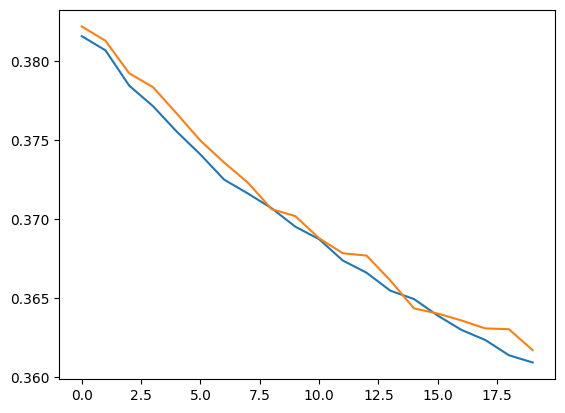

In [ ]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [ ]:
(x_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model=Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(512,activation='relu'))
model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist=model.fit(x_train,y_train,epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6680 - loss: 1.4044 - val_accuracy: 0.9379 - val_loss: 0.2480
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9408 - loss: 0.2353 - val_accuracy: 0.9492 - val_loss: 0.2087
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9598 - loss: 0.1661 - val_accuracy: 0.9637 - val_loss: 0.1406
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9681 - loss: 0.1242 - val_accuracy: 0.9624 - val_loss: 0.1611
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9704 - loss: 0.1087 - val_accuracy: 0.9664 - val_loss: 0.1529


In [ ]:
y_prod=model.predict(X_test)
y_pred=y_prod.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
accuracy_score(y_test,y_pred)

0.9687

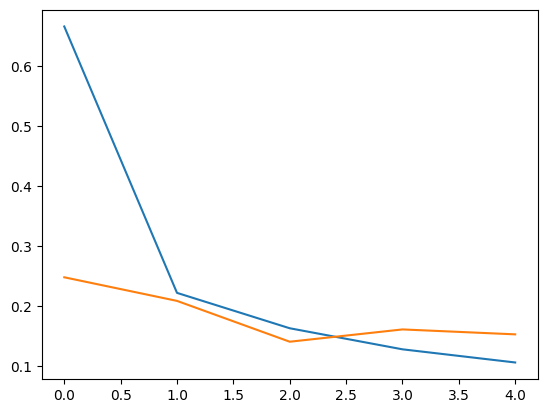

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

In [ ]:
import time
def fib(n):
  if n==0 or n==1:
    return 1
  else:
    return fib(n-1)+fib(n-2)

In [ ]:
start=time.time()
fib(30)
print(time.time()-start)

0.17037534713745117


In [ ]:
import time
def fib(n,d):
  if n in d:
    return n
  else:
    d[n] = fib(n-1,d)+fib(n-2,d)
    return d[n]

In [ ]:
start=time.time()
d={0:1,1:1}
fib(30,d)
print(time.time()-start)

0.00010895729064941406


In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.corr()['Outcome']

,Outcome
Pregnancies,0.221898
Glucose,0.466581
BloodPressure,0.065068
SkinThickness,0.074752
Insulin,0.130548
BMI,0.292695
DiabetesPedigreeFunction,0.173844
Age,0.238356
Outcome,1.000000


In [ ]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler=StandardScaler()
X=scaler.fit_transform(X)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=1)

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, BatchNormalization, Dropout

In [ ]:
model=Sequential()
model.add(Dense(32,activation='relu', input_dim=8))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train,y_train, batch_size=32, validation_data=(X_test,y_test), epochs=10)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.3480 - loss: 0.8556 - val_accuracy: 0.3961 - val_loss: 0.7771
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4124 - loss: 0.7552 - val_accuracy: 0.5065 - val_loss: 0.7108
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5418 - loss: 0.6894 - val_accuracy: 0.6234 - val_loss: 0.6542
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6868 - loss: 0.6296 - val_accuracy: 0.6753 - val_loss: 0.6126
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7010 - loss: 0.6081 - val_accuracy: 0.7208 - val_loss: 0.5818
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7367 - loss: 0.5719 - val_accuracy: 0.7532 - val_loss: 0.5560
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7741 - loss: 0.5465 - val_accuracy: 0.7792 - val_loss: 0.5351
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7507 - loss: 0.5450 - val_accuracy: 0.7792 - val_loss

In [ ]:
pip install -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 7.6 MB/s eta 0:00:00


In [ ]:
import kerastuner as kt

/tmp/ipython-input-1654478174.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [ ]:
def build_model(hp):
  model=Sequential()

  units=hp.Int('units', min_value=8,max_value=256, step=8)

  model.add(Dense(units=units, activation='relu', kernel_regularizer=tensorflow.keras.regularizers.l2(0.03),input_dim=8))
  model.add(BatchNormalization())
  model.add(Dropout(hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)))
  model.add(Dense(1, activation='sigmoid'))

  optimizer=hp.Choice('optimizer', values=['adam','rmsprop','adadelta','sgd'])

  model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

  return model

In [ ]:
tuner=kt.RandomSearch(build_model,
                      objective='val_accuracy',
                      max_trials=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 5 Complete [00h 00m 04s]
val_accuracy: 0.8246753215789795

Best val_accuracy So Far: 0.8246753215789795
Total elapsed time: 00h 00m 26s


In [ ]:
model = tuner.get_best_models(num_models=1)[0]
model

<Sequential name=sequential, built=True>

In [ ]:
hist=model.fit(X_train,y_train,epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7174 - loss: 0.9749 - val_accuracy: 0.8182 - val_loss: 0.9929
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7544 - loss: 0.9409 - val_accuracy: 0.7987 - val_loss: 0.9709
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7364 - loss: 0.9496 - val_accuracy: 0.7987 - val_loss: 0.9483
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7498 - loss: 0.9091 - val_accuracy: 0.7792 - val_loss: 0.9283
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7493 - loss: 0.8959 - val_accuracy: 0.7857 - val_loss: 0.9199
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7643 - loss: 0.8590 - val_accuracy: 0.7922 - val_loss: 0.8920
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7521 - loss: 0.8613 - val_accuracy: 0.7792 - val_loss: 0.8777
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7678 - loss: 0.8006 - val_accuracy: 0.7922 - val_loss